<a href="https://colab.research.google.com/github/lidia1900/Curso-IA-Cartagena/blob/main/dia1/2_los_tres_ingredientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerías

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_iris
!pip install torchviz # Install torchviz
from torchviz import make_dot

In [3]:
! pip install torchviz

# Iris dataset

In [5]:
# En PyTorch, los datasets deben heredar de torch.utils.data.Dataset
class IrisDataset(Dataset):
    # Inicializamos el dataset cargando los datos
    def __init__(self):
        data = load_iris()
        self.X = torch.tensor(
            data.data, dtype=torch.float32
        )  # (150, 4)
        self.y = torch.tensor(
            data.target, dtype=torch.long
        )  # (150,)

    # PyTorch necesita saber el tamaño del dataset
    def __len__(self):
        return self.X.shape[0]

    # PyTorch necesita poder indexar el dataset
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [6]:
full_iris_dataset = IrisDataset()

In [7]:
# ejemplos de muestras
for i in [1, 50, 100]:
    x, y = full_iris_dataset[i]
    print(f"Muestra {i}: x = {x}, y = {y}")

Muestra 1: x = tensor([4.9000, 3.0000, 1.4000, 0.2000]), y = 0
Muestra 50: x = tensor([7.0000, 3.2000, 4.7000, 1.4000]), y = 1
Muestra 100: x = tensor([6.3000, 3.3000, 6.0000, 2.5000]), y = 2


In [8]:
len(full_iris_dataset)

150

# Definición de la red

In [9]:
class IrisRed(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.fc1(x)   # (B, 3)
        return h

# el softmax no se suele incluir en el modelo porque
# 1) la función de pérdida CrossEntropyLoss ya lo incluye
# 2) y porque en inferencia se suele usar argmax (selección de la clase con mayor puntuación)

# Grafo computacional

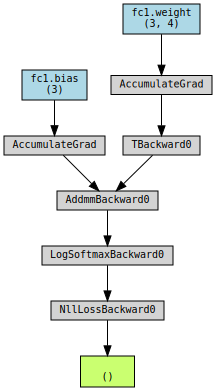

In [10]:
# Instanciamos el modelo y el loss
# En PyTorch, el loss y el modelo suelen ser instanciados por separado
model = IrisRed()
criterion = nn.CrossEntropyLoss()

# Input dummy (batch size = 5)
x = torch.randn(5, 4, requires_grad=False)

# Forward
y = model(x)
# Loss
target = torch.tensor([1, 0, 2, 1, 2])  # clase verdadera
loss = criterion(y, target)


# Crear grafo computacional
dot = make_dot(loss, params=dict(model.named_parameters()))

# Mostrar o guardar
dot

# Stochastic Gradient Descent, dividr en batches

In [11]:
# esta función devuelve un iterador sobre batches
dataloader = DataLoader(full_iris_dataset, batch_size=16, shuffle=True)
# por otro lado, la red se ha definido para procesar batches de datos

# Juntamos los tres ingredientes

In [12]:
# instanciar modelo, loss y optimizador
# si se dispone de GPU, mover el modelo a GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# la red se inicializa a pesos aleatorios cada vez que se instancia
model = IrisRed().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

In [13]:
num_epochs = 100
# durante un número de epochs
for epoch in range(1, num_epochs + 1):
    # poner el modelo en modo entrenamiento
    model.train()
    # para llevar la cuenta del loss
    running_loss = 0.0
    n_seen = 0
    for xB, yB in dataloader:
        xB, yB = xB.to(device), yB.to(device)
        optimizer.zero_grad()      # reset gradientes
        logits = model(xB)         # forward
        loss = criterion(logits, yB)
        loss.backward()            # backward
        optimizer.step()           # update
        running_loss += loss.item() * xB.size(0) # para llevar la cuenta del loss
        n_seen += xB.size(0)           # para llevar la cuenta del loss
    epoch_loss = running_loss / n_seen # loss medio en la epoch
    print(f"Epoch {epoch:03d} | train_loss = {epoch_loss:.4f}") # reportamos el loss

Epoch 001 | train_loss = 1.7087
Epoch 002 | train_loss = 1.1542
Epoch 003 | train_loss = 1.0621
Epoch 004 | train_loss = 0.9988
Epoch 005 | train_loss = 0.9440
Epoch 006 | train_loss = 0.8906
Epoch 007 | train_loss = 0.8494
Epoch 008 | train_loss = 0.8139
Epoch 009 | train_loss = 0.7762
Epoch 010 | train_loss = 0.7514
Epoch 011 | train_loss = 0.7181
Epoch 012 | train_loss = 0.6992
Epoch 013 | train_loss = 0.6739
Epoch 014 | train_loss = 0.6606
Epoch 015 | train_loss = 0.6499
Epoch 016 | train_loss = 0.6256
Epoch 017 | train_loss = 0.6137
Epoch 018 | train_loss = 0.6122
Epoch 019 | train_loss = 0.5974
Epoch 020 | train_loss = 0.5846
Epoch 021 | train_loss = 0.5726
Epoch 022 | train_loss = 0.5611
Epoch 023 | train_loss = 0.5571
Epoch 024 | train_loss = 0.5482
Epoch 025 | train_loss = 0.5429
Epoch 026 | train_loss = 0.5378
Epoch 027 | train_loss = 0.5266
Epoch 028 | train_loss = 0.5225
Epoch 029 | train_loss = 0.5272
Epoch 030 | train_loss = 0.5113
Epoch 031 | train_loss = 0.5158
Epoch 03

# Ejercicio

Divide el dataset en train y test, y entrena el modelo durante 100 epochs. Evalúa el accuracy en el conjunto de test.
- `torch.utils.data.random_split`
- `torch.argmax` con el parámetro `dim` (indica la dimensión a reducir). `dim` es equivalente a `axis` en NumPy. Seguntamente tengáis que usar `dim=1` para reducir la dimensión de las clases.

Recuerda poner el modelo en modo evaluación con `model.eval()` cuando evalúes en el conjunto de test.

In [ ]:
# Ejercicio
